In [9]:
import pandas as pd
from pathlib import Path

ESM_XLSX = Path("./cumulative_carbon_density_biomass_global_paper.xlsx")
IAM_XLSX = Path("./cumulative_carbon_density_2020_2100_corrected_new.xlsx")

esm_df = pd.read_excel(ESM_XLSX)
iam_df = pd.read_excel(IAM_XLSX)

#Map ssp126 -> SSP1-26, ssp245 -> SSP2-45, etc.
ssp_map = {
'ssp126': 'SSP1-26',
'ssp245': 'SSP2-45',
'ssp370': 'SSP3-70',
'ssp585': 'SSP5-85'
}
esm_df['SSP_std'] = esm_df['SSP'].map(ssp_map)
iam_df['SSP_std'] = iam_df['scenario'].str.strip()

#Rename columns for merging
iam_df = iam_df.rename(columns={
"Cumulative_Carbon_Density_2020_2100_tCO2_ha": "IAM_CarbonDensity",
"model": "IAM_model"
})

#Merge on standardized SSP
merged = esm_df.merge(
iam_df[["IAM_model", "SSP_std", "IAM_CarbonDensity"]],
left_on="SSP_std",
right_on="SSP_std",
how="inner"
)

merged["scaling_factor"] = merged["CumulativeCarbonDensity_tCO2_per_ha"] / merged["IAM_CarbonDensity"]

#Save to Excel
output_path = "scaling_factors_output_per_esm_corrected_new_new.xlsx"
merged.to_excel(output_path, index=False)

print(f"Saved scaling factors to {output_path}")

Saved scaling factors to scaling_factors_output_per_esm_corrected_new_new.xlsx


In [ ]:
#monte carlo method below#

COMPLETE MONTE CARLO vs DETERMINISTIC SCALING FACTOR ANALYSIS

Step 1: Examining ESM data structure...
=== EXAMINING ACTUAL ESM DATA STRUCTURE ===
Data shape: (36, 5)
Columns: ['LandModel', 'ESM', 'Landuse', 'SSP', 'CumulativeCarbonDensity_tCO2_per_ha']

All data rows:
   LandModel            ESM   Landuse     SSP  \
0      jules  mpi-esm1-2-hr   agtobio  ssp126   
1      jules    ukesm1-0-ll   agtobio  ssp126   
2      jules   ipsl-cm6a-lr   agtobio  ssp126   
3      jules  mpi-esm1-2-hr   agtobio  ssp370   
4      jules    ukesm1-0-ll   agtobio  ssp370   
5      jules   ipsl-cm6a-lr   agtobio  ssp370   
6      jules  mpi-esm1-2-hr  nattobio  ssp126   
7      jules    ukesm1-0-ll  nattobio  ssp126   
8      jules   ipsl-cm6a-lr  nattobio  ssp126   
9      jules  mpi-esm1-2-hr  nattobio  ssp370   
10     jules    ukesm1-0-ll  nattobio  ssp370   
11     jules   ipsl-cm6a-lr  nattobio  ssp370   
12    jsbach  mpi-esm1-2-hr   agtobio  ssp126   
13    jsbach    ukesm1-0-ll   agtobio  ssp12

/var/folders/6n/npd068v10ysgh8rlknlkg_zc0000gp/T/ipykernel_69214/3189181112.py:365: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=['Deterministic', 'Monte Carlo'],


Comparison visualization saved: monte_carlo_complete_analysis/deterministic_vs_monte_carlo_comparison.png


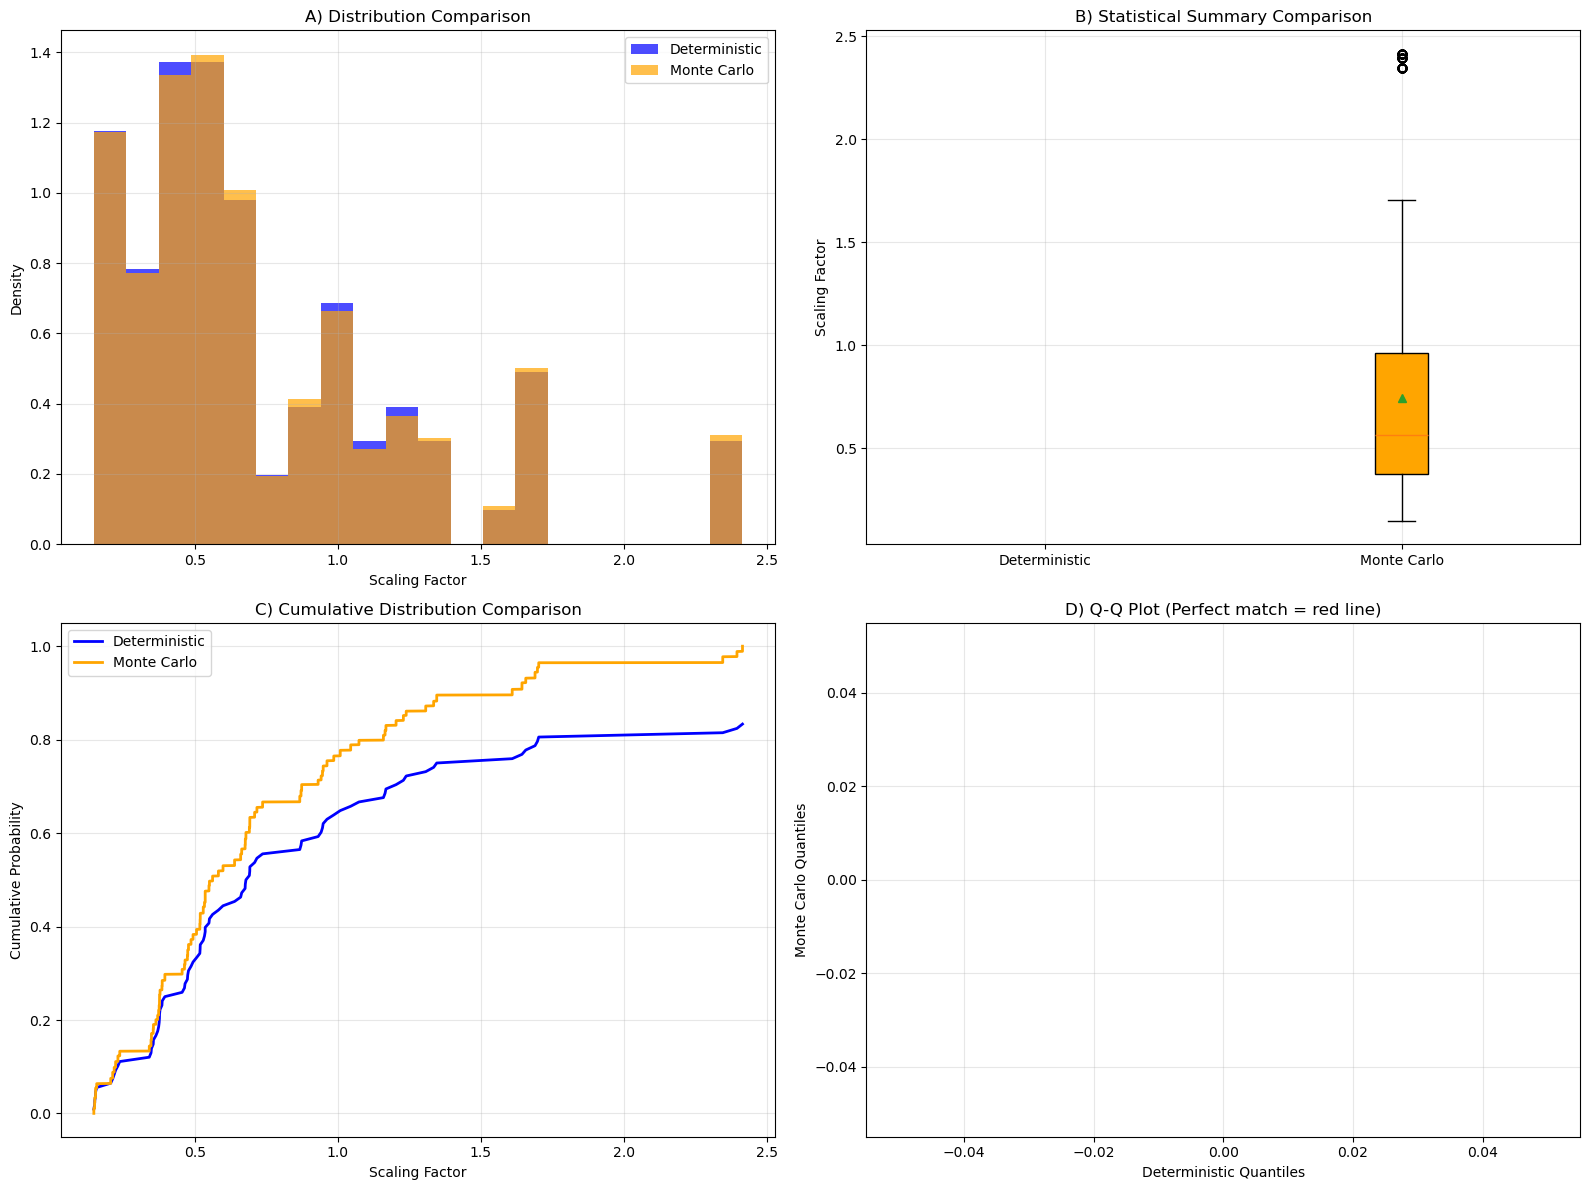


ANALYSIS COMPLETE!
All results saved to: monte_carlo_complete_analysis/


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def examine_esm_data_structure():
    """
    Examine the actual ESM data file to understand the structure
    """
    ESM_XLSX = Path("./cumulative_carbon_density_biomass_global_paper.xlsx")
    
    esm_df = pd.read_excel(ESM_XLSX)
    
    print("=== EXAMINING ACTUAL ESM DATA STRUCTURE ===")
    print(f"Data shape: {esm_df.shape}")
    print(f"Columns: {esm_df.columns.tolist()}")
    print(f"\nAll data rows:")
    print(esm_df)
    
    return esm_df

def load_and_prepare_data():
    """
    Load and prepare data from actual files
    """
    ESM_XLSX = Path("./cumulative_carbon_density_biomass_global_paper.xlsx")
    IAM_XLSX = Path("./cumulative_carbon_density_2020_2100_corrected_new.xlsx")
    
    # Load original data
    esm_df_original = pd.read_excel(ESM_XLSX)
    iam_df_original = pd.read_excel(IAM_XLSX)
    
    print("=== LOADING AND PREPARING DATA ===")
    print("Original ESM data:")
    print(esm_df_original)
    
    # Create working copies
    esm_df = esm_df_original.copy()
    iam_df = iam_df_original.copy()
    
    # Map SSP scenarios
    ssp_map = {
        'ssp126': 'SSP1-26',
        'ssp245': 'SSP2-45', 
        'ssp370': 'SSP3-70',
        'ssp585': 'SSP5-85'
    }
    
    if 'SSP' in esm_df.columns:
        esm_df['SSP_std'] = esm_df['SSP'].map(ssp_map)
    
    if 'scenario' in iam_df.columns:
        iam_df['SSP_std'] = iam_df['scenario'].str.strip()
        
    if 'model' in iam_df.columns:
        iam_df['IAM_model'] = iam_df['model']
    
    # Find carbon density columns
    esm_carbon_col = None
    iam_carbon_col = None
    
    for col in esm_df.columns:
        if 'carbon' in col.lower() and 'density' in col.lower():
            esm_carbon_col = col
            break
    
    for col in iam_df.columns:
        if 'carbon' in col.lower() and 'density' in col.lower():
            iam_carbon_col = col
            break
    
    print(f"\nData preparation results:")
    print(f"ESM carbon column: {esm_carbon_col}")
    print(f"IAM carbon column: {iam_carbon_col}")
    print(f"ESM SSPs: {esm_df['SSP_std'].unique() if 'SSP_std' in esm_df.columns else 'Not found'}")
    print(f"IAM SSPs: {iam_df['SSP_std'].unique() if 'SSP_std' in iam_df.columns else 'Not found'}")
    
    return esm_df, iam_df, esm_carbon_col, iam_carbon_col

def calculate_deterministic_scaling_factors(esm_df, iam_df, esm_carbon_col, iam_carbon_col):
    """
    DETERMINISTIC METHOD: Calculate scaling factors for ALL combinations
    """
    print("\n=== DETERMINISTIC METHOD: ALL COMBINATIONS ===")
    
    # Merge all combinations
    merged = esm_df.merge(
        iam_df[['IAM_model', 'SSP_std', iam_carbon_col]],
        left_on='SSP_std',
        right_on='SSP_std',
        how='inner'
    )
    
    print(f"Merged data shape: {merged.shape}")
    print(f"Total ESM-LUC-IAM combinations: {len(merged)}")
    
    # Calculate scaling factors: ESM_density / IAM_density
    merged['scaling_factor'] = merged[esm_carbon_col] / merged[iam_carbon_col]
    
    # Summary statistics
    det_stats = {
        'method': 'Deterministic',
        'n_combinations': len(merged),
        'mean': merged['scaling_factor'].mean(),
        'median': merged['scaling_factor'].median(),
        'std': merged['scaling_factor'].std(),
        'min': merged['scaling_factor'].min(),
        'max': merged['scaling_factor'].max(),
        'p2_5': np.percentile(merged['scaling_factor'], 2.5),
        'p25': np.percentile(merged['scaling_factor'], 25),
        'p75': np.percentile(merged['scaling_factor'], 75),
        'p97_5': np.percentile(merged['scaling_factor'], 97.5)
    }
    
    print(f"\nDETERMINISTIC RESULTS:")
    print(f"Number of combinations: {det_stats['n_combinations']}")
    print(f"Mean scaling factor: {det_stats['mean']:.3f}")
    print(f"Standard deviation: {det_stats['std']:.3f}")
    print(f"Range: [{det_stats['min']:.3f}, {det_stats['max']:.3f}]")
    print(f"95% Range: [{det_stats['p2_5']:.3f}, {det_stats['p97_5']:.3f}]")
    
    # Show breakdown by components
    if 'Model' in merged.columns:
        print(f"\nBreakdown by Land Model:")
        model_stats = merged.groupby('Model')['scaling_factor'].agg(['count', 'mean', 'std'])
        print(model_stats)
    
    if 'Landuse' in merged.columns:
        print(f"\nBreakdown by Land Use:")
        landuse_stats = merged.groupby('Landuse')['scaling_factor'].agg(['count', 'mean', 'std'])
        print(landuse_stats)
    
    return merged, det_stats

def monte_carlo_scaling_factors(esm_df, iam_df, esm_carbon_col, iam_carbon_col, n_iterations=1000, random_seed=42):
    """
    MONTE CARLO METHOD: Random sampling of combinations
    """
    print(f"\n=== MONTE CARLO METHOD: {n_iterations} RANDOM SAMPLES ===")
    
    np.random.seed(random_seed)
    
    mc_results = []
    unique_ssps = esm_df['SSP_std'].dropna().unique()
    unique_iams = iam_df['IAM_model'].unique()
    
    print(f"Monte Carlo setup:")
    print(f"SSPs: {unique_ssps}")
    print(f"IAM models: {unique_iams}")
    
    # Count available combinations per SSP
    for ssp in unique_ssps:
        ssp_data = esm_df[esm_df['SSP_std'] == ssp]
        print(f"  {ssp}: {len(ssp_data)} ESM combinations available")
    
    seed_counter = 0
    
    for iteration in range(n_iterations):
        if iteration % 200 == 0:
            print(f"  Iteration {iteration}/{n_iterations}")
        
        for ssp in unique_ssps:
            # Filter ESM data for this SSP
            esm_ssp = esm_df[esm_df['SSP_std'] == ssp].copy()
            
            if len(esm_ssp) == 0:
                continue
            
            for iam_model in unique_iams:
                # Get IAM carbon density
                iam_data = iam_df[
                    (iam_df['SSP_std'] == ssp) & 
                    (iam_df['IAM_model'] == iam_model)
                ]
                
                if len(iam_data) == 0:
                    continue
                
                iam_density = iam_data[iam_carbon_col].values[0]
                
                # Generate random seed
                valid_seed = (iteration * len(unique_iams) + seed_counter) % (2**32 - 1)
                seed_counter += 1
                
                # RANDOM SAMPLING: Pick ONE combination
                sampled = esm_ssp.sample(n=1, random_state=valid_seed)
                
                esm_density = sampled[esm_carbon_col].values[0]
                
                # Calculate scaling factor
                if iam_density != 0:
                    scaling_factor = esm_density / iam_density
                else:
                    scaling_factor = np.nan
                
                # Store results
                result = {
                    'iteration': iteration,
                    'SSP': ssp,
                    'IAM_model': iam_model,
                    'ESM_CarbonDensity': esm_density,
                    'IAM_CarbonDensity': iam_density,
                    'scaling_factor': scaling_factor
                }
                
                # Add available columns from ESM data
                for col in ['Model', 'Landuse']:
                    if col in sampled.columns:
                        result[col] = sampled[col].values[0]
                
                mc_results.append(result)
    
    mc_df = pd.DataFrame(mc_results)
    
    # Remove NaN values
    mc_clean = mc_df.dropna(subset=['scaling_factor'])
    
    print(f"\nMONTE CARLO RESULTS:")
    print(f"Total iterations: {len(mc_df)}")
    print(f"Valid results: {len(mc_clean)}")
    print(f"NaN values removed: {len(mc_df) - len(mc_clean)}")
    
    if len(mc_clean) > 0:
        # Calculate statistics
        mc_stats = {
            'method': 'Monte Carlo',
            'n_samples': len(mc_clean),
            'mean': mc_clean['scaling_factor'].mean(),
            'median': mc_clean['scaling_factor'].median(),
            'std': mc_clean['scaling_factor'].std(),
            'min': mc_clean['scaling_factor'].min(),
            'max': mc_clean['scaling_factor'].max(),
            'p2_5': np.percentile(mc_clean['scaling_factor'], 2.5),
            'p25': np.percentile(mc_clean['scaling_factor'], 25),
            'p75': np.percentile(mc_clean['scaling_factor'], 75),
            'p97_5': np.percentile(mc_clean['scaling_factor'], 97.5)
        }
        
        print(f"Mean scaling factor: {mc_stats['mean']:.3f}")
        print(f"Median scaling factor: {mc_stats['median']:.3f}")
        print(f"Standard deviation: {mc_stats['std']:.3f}")
        print(f"Range: [{mc_stats['min']:.3f}, {mc_stats['max']:.3f}]")
        print(f"95% CI: [{mc_stats['p2_5']:.3f}, {mc_stats['p97_5']:.3f}]")
        print(f"IQR: [{mc_stats['p25']:.3f}, {mc_stats['p75']:.3f}]")
        
        # Sampling frequency
        if 'Model' in mc_clean.columns:
            print(f"\nSampling frequency by Model:")
            print(mc_clean['Model'].value_counts())
        
        if 'Landuse' in mc_clean.columns:
            print(f"\nSampling frequency by Landuse:")
            print(mc_clean['Landuse'].value_counts())
    
    return mc_df, mc_stats if len(mc_clean) > 0 else None

def compare_deterministic_vs_monte_carlo(det_stats, mc_stats, det_data, mc_data):
    """
    COMPARISON: Deterministic vs Monte Carlo methods
    """
    print("\n" + "="*60)
    print("=== DETERMINISTIC vs MONTE CARLO COMPARISON ===")
    print("="*60)
    
    if mc_stats is None:
        print("Cannot compare: Monte Carlo failed")
        return None
    
    # Create comparison table
    comparison = pd.DataFrame({
        'Deterministic': [
            det_stats['n_combinations'],
            det_stats['mean'],
            det_stats['median'], 
            det_stats['std'],
            det_stats['min'],
            det_stats['max'],
            f"[{det_stats['p2_5']:.3f}, {det_stats['p97_5']:.3f}]",
            f"[{det_stats['p25']:.3f}, {det_stats['p75']:.3f}]"
        ],
        'Monte Carlo': [
            mc_stats['n_samples'],
            mc_stats['mean'],
            mc_stats['median'],
            mc_stats['std'], 
            mc_stats['min'],
            mc_stats['max'],
            f"[{mc_stats['p2_5']:.3f}, {mc_stats['p97_5']:.3f}]",
            f"[{mc_stats['p25']:.3f}, {mc_stats['p75']:.3f}]"
        ],
        'Difference': [
            f"{mc_stats['n_samples'] - det_stats['n_combinations']} samples",
            f"{mc_stats['mean'] - det_stats['mean']:+.3f}",
            f"{mc_stats['median'] - det_stats['median']:+.3f}",
            f"{mc_stats['std'] - det_stats['std']:+.3f}",
            f"{mc_stats['min'] - det_stats['min']:+.3f}",
            f"{mc_stats['max'] - det_stats['max']:+.3f}",
            "Range comparison",
            "IQR comparison"
        ]
    }, index=[
        'Sample Size', 'Mean', 'Median', 'Std Dev', 'Minimum', 'Maximum', 
        '95% Range/CI', 'IQR'
    ])
    
    print("\nCOMPARISON TABLE:")
    print(comparison)
    
    print(f"\nKEY INSIGHTS:")
    
    # Mean difference
    mean_diff = abs(mc_stats['mean'] - det_stats['mean'])
    mean_pct = (mean_diff / det_stats['mean']) * 100
    print(f"1. Mean difference: {mean_diff:.3f} ({mean_pct:.1f}%)")
    
    # Range comparison
    det_range = det_stats['max'] - det_stats['min']
    mc_range = mc_stats['max'] - mc_stats['min']
    range_diff = abs(mc_range - det_range)
    print(f"2. Range difference: {range_diff:.3f}")
    
    # Coverage comparison
    det_coverage = det_stats['p97_5'] - det_stats['p2_5']
    mc_coverage = mc_stats['p97_5'] - mc_stats['p2_5']
    coverage_diff = abs(mc_coverage - det_coverage)
    print(f"3. 95% coverage difference: {coverage_diff:.3f}")
    
    # Method assessment
    print(f"\n4. METHOD ASSESSMENT:")
    if mean_pct < 5:
        print(f"   - Results are VERY SIMILAR (mean diff < 5%)")
        print(f"   - Monte Carlo provides statistical framework for same information")
    elif mean_pct < 10:
        print(f"   - Results are SIMILAR (mean diff < 10%)")
    else:
        print(f"   - Results show MEANINGFUL DIFFERENCES")
    
    if abs(det_stats['min'] - mc_stats['p2_5']) < 0.1 and abs(det_stats['max'] - mc_stats['p97_5']) < 0.1:
        print(f"   - Monte Carlo 95% CI ≈ Deterministic range")
        print(f"   - Limited ensemble size constrains uncertainty")
    
    return comparison

def create_comparison_visualization(det_data, mc_data, output_dir):
    """
    Create visualization comparing deterministic vs Monte Carlo
    """
    print("\n=== CREATING COMPARISON VISUALIZATION ===")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Histograms comparison
    ax1.hist(det_data['scaling_factor'], bins=20, alpha=0.7, label='Deterministic', 
             color='blue', density=True)
    ax1.hist(mc_data['scaling_factor'], bins=20, alpha=0.7, label='Monte Carlo',
             color='orange', density=True)
    ax1.set_xlabel('Scaling Factor')
    ax1.set_ylabel('Density')
    ax1.set_title('A) Distribution Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Box plots comparison
    box_data = [det_data['scaling_factor'], mc_data['scaling_factor']]
    bp = ax2.boxplot(box_data, labels=['Deterministic', 'Monte Carlo'], 
                     patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('orange')
    ax2.set_ylabel('Scaling Factor')
    ax2.set_title('B) Statistical Summary Comparison')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative distributions
    det_sorted = np.sort(det_data['scaling_factor'])
    mc_sorted = np.sort(mc_data['scaling_factor'])
    det_cdf = np.arange(1, len(det_sorted) + 1) / len(det_sorted)
    mc_cdf = np.arange(1, len(mc_sorted) + 1) / len(mc_sorted)
    
    ax3.plot(det_sorted, det_cdf, label='Deterministic', linewidth=2, color='blue')
    ax3.plot(mc_sorted, mc_cdf, label='Monte Carlo', linewidth=2, color='orange')
    ax3.set_xlabel('Scaling Factor')
    ax3.set_ylabel('Cumulative Probability')
    ax3.set_title('C) Cumulative Distribution Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Q-Q plot
    from scipy import stats
    det_quantiles = np.percentile(det_data['scaling_factor'], np.linspace(1, 99, 50))
    mc_quantiles = np.percentile(mc_data['scaling_factor'], np.linspace(1, 99, 50))
    
    ax4.scatter(det_quantiles, mc_quantiles, alpha=0.7, s=50)
    min_val = min(det_quantiles.min(), mc_quantiles.min())
    max_val = max(det_quantiles.max(), mc_quantiles.max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax4.set_xlabel('Deterministic Quantiles')
    ax4.set_ylabel('Monte Carlo Quantiles')
    ax4.set_title('D) Q-Q Plot (Perfect match = red line)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save visualization
    viz_file = output_dir / "deterministic_vs_monte_carlo_comparison.png"
    plt.savefig(viz_file, dpi=300, bbox_inches='tight')
    print(f"Comparison visualization saved: {viz_file}")
    
    plt.show()
    
    return fig

def save_all_results(esm_df, iam_df, det_data, det_stats, mc_data, mc_stats, comparison):
    """
    Save all results with proper naming
    """
    print(f"\n=== SAVING ALL MONTE CARLO ANALYSIS RESULTS ===")
    
    # Create output directory
    output_dir = Path("monte_carlo_complete_analysis")
    output_dir.mkdir(exist_ok=True)
    
    # Save datasets
    esm_df.to_excel(output_dir / "01_esm_input_data.xlsx", index=False)
    iam_df.to_excel(output_dir / "02_iam_input_data.xlsx", index=False)
    
    # Save deterministic results
    det_data.to_excel(output_dir / "03_deterministic_all_combinations.xlsx", index=False)
    
    # Save Monte Carlo results
    if mc_data is not None and len(mc_data) > 0:
        mc_clean = mc_data.dropna(subset=['scaling_factor'])
        mc_clean.to_excel(output_dir / "04_monte_carlo_sample_results.xlsx", index=False)
    
    # Save statistics comparison
    if mc_stats is not None:
        stats_comparison = pd.DataFrame({
            'Statistic': ['Sample_Size', 'Mean', 'Median', 'Std_Dev', 'Minimum', 'Maximum', 
                         'Percentile_2_5', 'Percentile_25', 'Percentile_75', 'Percentile_97_5'],
            'Deterministic': [det_stats['n_combinations'], det_stats['mean'], det_stats['median'],
                             det_stats['std'], det_stats['min'], det_stats['max'],
                             det_stats['p2_5'], det_stats['p25'], det_stats['p75'], det_stats['p97_5']],
            'Monte_Carlo': [mc_stats['n_samples'], mc_stats['mean'], mc_stats['median'],
                           mc_stats['std'], mc_stats['min'], mc_stats['max'],
                           mc_stats['p2_5'], mc_stats['p25'], mc_stats['p75'], mc_stats['p97_5']]
        })
        stats_comparison.to_excel(output_dir / "05_statistics_comparison.xlsx", index=False)
    
    # Save detailed comparison
    if comparison is not None:
        comparison.to_excel(output_dir / "06_detailed_method_comparison.xlsx")
    
    # Create summary report
    summary_file = output_dir / "07_monte_carlo_analysis_summary.txt"
    with open(summary_file, 'w') as f:
        f.write("MONTE CARLO vs DETERMINISTIC SCALING FACTOR ANALYSIS\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Analysis Date: {pd.Timestamp.now()}\n\n")
        
        f.write("INPUT DATA:\n")
        f.write(f"- ESM combinations: {len(esm_df)}\n")
        f.write(f"- IAM models: {len(iam_df['IAM_model'].unique()) if 'IAM_model' in iam_df.columns else 'Unknown'}\n\n")
        
        f.write("DETERMINISTIC METHOD:\n")
        f.write(f"- Uses ALL {det_stats['n_combinations']} combinations\n")
        f.write(f"- Mean scaling factor: {det_stats['mean']:.3f}\n")
        f.write(f"- Range: [{det_stats['min']:.3f}, {det_stats['max']:.3f}]\n\n")
        
        if mc_stats:
            f.write("MONTE CARLO METHOD:\n")
            f.write(f"- Random sampling with {mc_stats['n_samples']} iterations\n")
            f.write(f"- Mean scaling factor: {mc_stats['mean']:.3f}\n")
            f.write(f"- 95% Confidence Interval: [{mc_stats['p2_5']:.3f}, {mc_stats['p97_5']:.3f}]\n\n")
            
            f.write("COMPARISON:\n")
            mean_diff = abs(mc_stats['mean'] - det_stats['mean'])
            mean_pct = (mean_diff / det_stats['mean']) * 100
            f.write(f"- Mean difference: {mean_diff:.3f} ({mean_pct:.1f}%)\n")
            
            if mean_pct < 5:
                f.write("- CONCLUSION: Methods give very similar results\n")
                f.write("- Monte Carlo adds statistical framework to same information\n")
    
    print(f"\nALL OUTPUT FILES SAVED TO: {output_dir}/")
    print(f"Files created:")
    for file in sorted(output_dir.glob("*")):
        print(f"  - {file.name}")
    
    return output_dir

def main():
    """
    Complete Monte Carlo analysis with deterministic comparison
    """
    print("=" * 70)
    print("COMPLETE MONTE CARLO vs DETERMINISTIC SCALING FACTOR ANALYSIS")
    print("=" * 70)
    
    try:
        # Step 1: Examine data structure
        print("\nStep 1: Examining ESM data structure...")
        esm_raw = examine_esm_data_structure()
        
        # Step 2: Load and prepare data
        print("\nStep 2: Loading and preparing data...")
        esm_df, iam_df, esm_carbon_col, iam_carbon_col = load_and_prepare_data()
        
        if esm_carbon_col is None or iam_carbon_col is None:
            print("ERROR: Cannot find carbon density columns")
            return None, None, None, None, None
        
        # Step 3: Deterministic method
        print("\nStep 3: Running deterministic analysis...")
        det_data, det_stats = calculate_deterministic_scaling_factors(
            esm_df, iam_df, esm_carbon_col, iam_carbon_col)
        
        # Step 4: Monte Carlo method
        print("\nStep 4: Running Monte Carlo analysis...")
        mc_data, mc_stats = monte_carlo_scaling_factors(
            esm_df, iam_df, esm_carbon_col, iam_carbon_col, n_iterations=1000)
        
        # Step 5: Compare methods
        print("\nStep 5: Comparing methods...")
        comparison = compare_deterministic_vs_monte_carlo(
            det_stats, mc_stats, det_data, mc_data.dropna(subset=['scaling_factor']) if mc_data is not None else None)
        
        # Step 6: Save all results
        print("\nStep 6: Saving results...")
        output_dir = save_all_results(esm_df, iam_df, det_data, det_stats, mc_data, mc_stats, comparison)
        
        # Step 7: Create visualization
        if mc_data is not None and len(mc_data) > 0:
            print("\nStep 7: Creating comparison visualization...")
            mc_clean = mc_data.dropna(subset=['scaling_factor'])
            create_comparison_visualization(det_data, mc_clean, output_dir)
        
        print(f"\n{'='*70}")
        print("ANALYSIS COMPLETE!")
        print(f"All results saved to: {output_dir}/")
        print(f"{'='*70}")
        
        return esm_df, iam_df, det_data, mc_data, comparison
        
    except Exception as e:
        print(f"Error in analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None, None, None

if __name__ == "__main__":
    esm_df, iam_df, det_results, mc_results, comparison = main()